# Landsat GQA step change investigation

<div class="alert alert-success">
Geometric Quality Assurance (GQA) metadata measure <b>georeferencing accuracy</b>, or how closely a satellite scene is located to its expected location. High values represent poorly georeferenced scenes.
</div>

## Summary of issue

* Certain Landsat WRS path/rows show a **sharp jump in GQA values** before and after Jan 1 2022, inferring a decrease in geometric positioning accuracy
* This is particularly clear in Torres Strait (e.g. "099067", "098067"), where GQA jumps by approximately 0.4-0.6 units (~10-15 m) after 2022
* Only Landsat 8 has sufficient data before and after 2022 to assess, although post-2022 Landsat 9 generally has elevated GQA consistent with Landsat 8

## Impact
* This jump in GQA degrades the DEA Coastlines data product, where sub-pixel coastline extraction leads to sharp artificial coastal change post-2022
* Example below at Moa Island, Torres Strait (https://maps.dea.ga.gov.au/#share=s-neS6Kcr8WcnvLTDJwdA68EVLo5J), where shorelines are artificially offset by 10-15 m to the north-east after January 2022

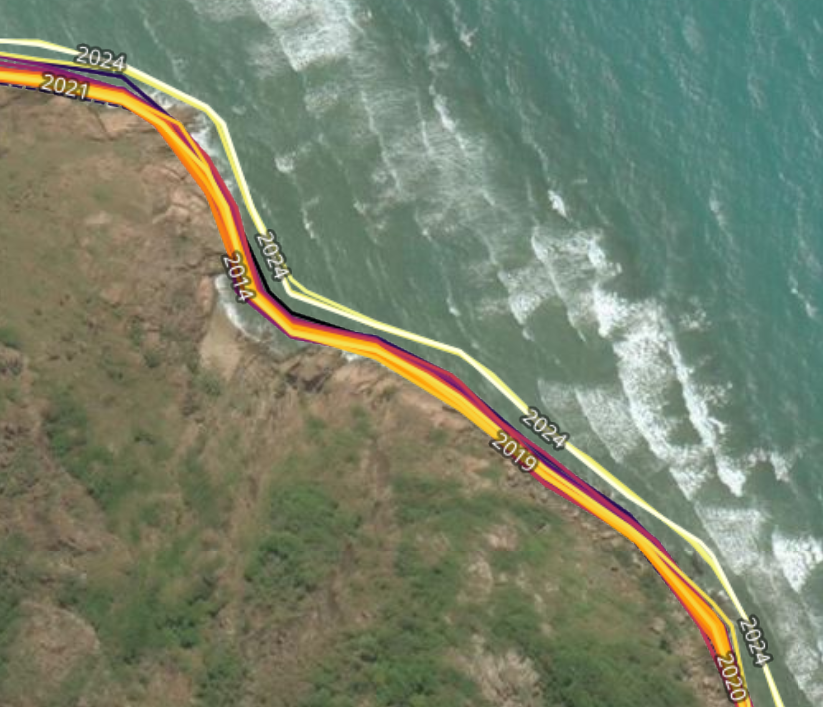

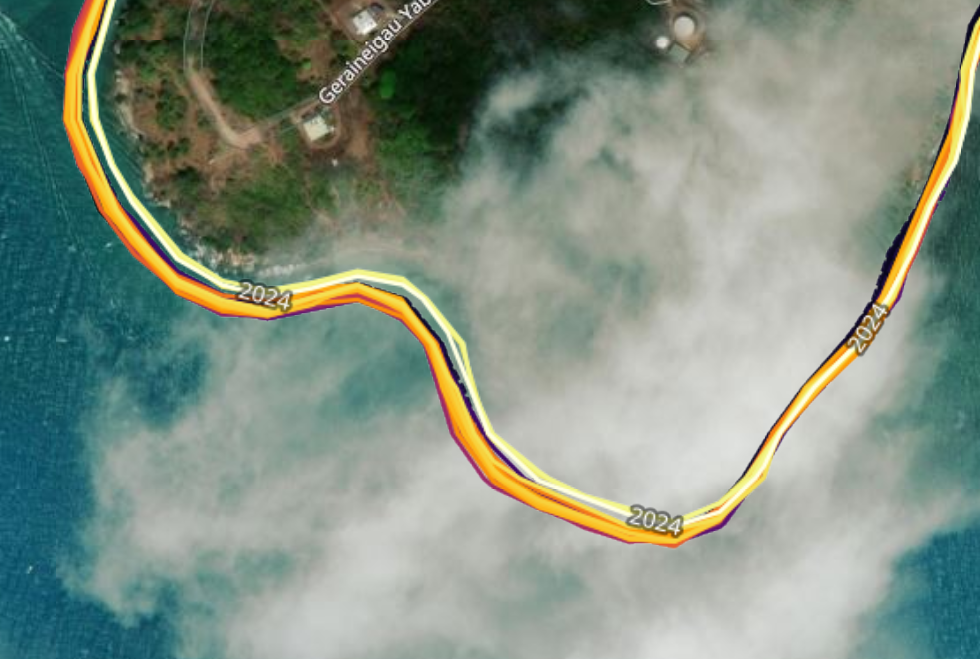

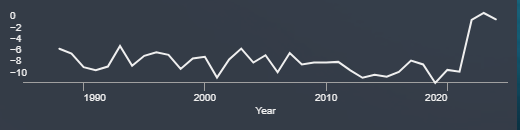


## Setup

In [1]:
import pandas as pd
from odc.geo import BoundingBox
import datacube
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

# Connect to datacube
dc = datacube.Datacube()


## Plot GQA time series for affected path/rows
Plot rolling median of GQA values for all Landsat sensors to view step-changes.

Torres Strait (worst affected area):

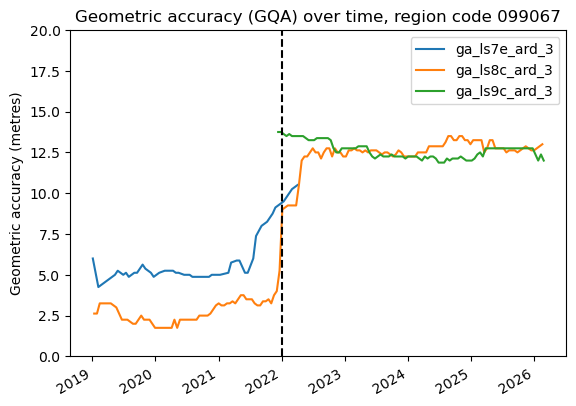

In [2]:
region_code = "099067"
products = ["ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"]

for product in products:
    dss = dc.find_datasets(
        product=product,
        time=("2019", None),
        region_code=region_code,
    )

    (
        pd.Series(
            {d.center_time: d.metadata.fields["gqa_iterative_mean_xy"] for d in dss},
            name="value",
        )
        .sort_index()
        .rolling(20, min_periods=5, center=True)
        .median()
        .multiply(25)
        .plot(label=product)
    )

plt.ylim(0, 20)
plt.axvline("2022-01-01", color="black", linestyle="--")
plt.legend()
plt.title(f"Geometric accuracy (GQA) over time, region code {region_code}");
plt.ylabel(f"Geometric accuracy (metres)");


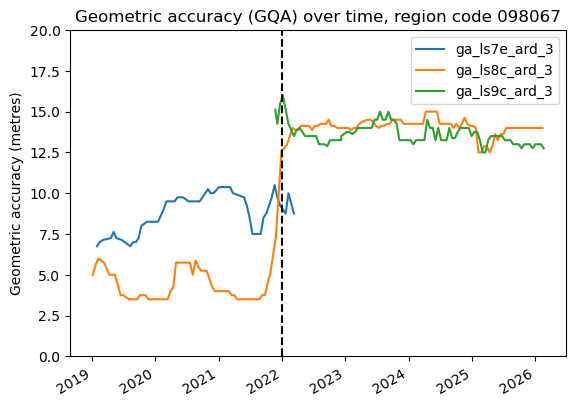

In [3]:
region_code = "098067"
products = ["ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"]

for product in products:
    dss = dc.find_datasets(
        product=product,
        time=("2019", None),
        region_code=region_code,
    )

    (
        pd.Series(
            {d.center_time: d.metadata.fields["gqa_iterative_mean_xy"] for d in dss},
            name="value",
        )
        .sort_index()
        .rolling(20, min_periods=5, center=True)
        .median()
        .multiply(25)
        .plot(label=product)
    )

plt.ylim(0, 20)
plt.axvline("2022-01-01", color="black", linestyle="--")
plt.legend()
plt.title(f"Geometric accuracy (GQA) over time, region code {region_code}");
plt.ylabel(f"Geometric accuracy (metres)");

Hobart, Tasmania:

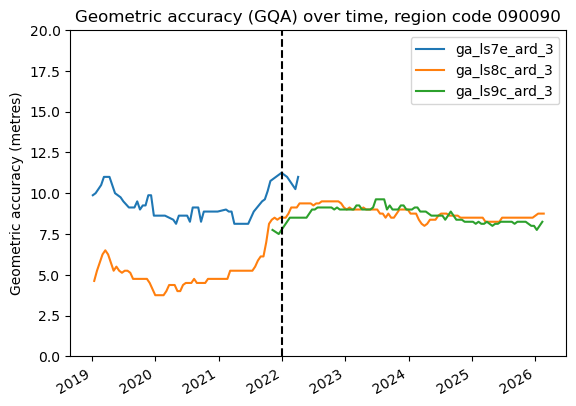

In [4]:
region_code = "090090"
products = ["ga_ls7e_ard_3", "ga_ls8c_ard_3", "ga_ls9c_ard_3"]

for product in products:
    dss = dc.find_datasets(
        product=product,
        time=("2019", None),
        region_code=region_code,
    )

    (
        pd.Series(
            {d.center_time: d.metadata.fields["gqa_iterative_mean_xy"] for d in dss},
            name="value",
        )
        .sort_index()
        .rolling(20, min_periods=5, center=True)
        .median()
        .multiply(25)
        .plot(label=product)
    )

plt.ylim(0, 20)
plt.axvline("2022-01-01", color="black", linestyle="--")
plt.legend()
plt.title(f"Geometric accuracy (GQA) over time, region code {region_code}");
plt.ylabel(f"Geometric accuracy (metres)");

## Compare difference in GQA over time for all Landsat path/rows

In [5]:
# Bounding box
bbox = BoundingBox(left=138, bottom=-18, right=147, top=-9)  # N Aus
bbox = BoundingBox(left=112, bottom=-45, right=155, top=-9)  # all Aus

# Extract relevant path/rows to compare
wrs_gdf = gpd.read_file("/gdata1/data/satellite_grids/ga_ls_path_row_grid.geojson").set_index("WRSPR")
wrs_gdf_subset = wrs_gdf.cx[bbox.left : bbox.right, bbox.top : bbox.bottom]
wrs_gdf_subset.explore()

### Iterate through every path/row

Calculate the following fields for Landsat 8:

* Absolute GQA difference between median GQA pre 2022, and median GQA post 2022
* Count of valid observations
* Mann Whitney significance to assess whether post 2022 GQA values are significantly greater or smaller than pre-2022 GQA

In [13]:
gqa_diff_dict = {}
gqa_n_dict = {}
gqa_sig_dict = {}

for wrspr in wrs_gdf_subset.index:

    region_code = f"{wrspr:06}"

    dss = dc.find_datasets(
        product="ga_ls8c_ard_3",
        time=("2019", None),
        region_code=region_code,
    )

    # Extract GQA and multiply by 25 to get metres
    gqa_df = pd.Series(
        {d.center_time: d.metadata.fields["gqa_iterative_mean_xy"] for d in dss},
        name="value",
    ).sort_index() * 25.0
    pre_2022 = gqa_df.loc[:"2021-12-31"]
    post_2022 = gqa_df.loc["2022-01-01":]
    gqa_diff_dict[wrspr] = round(pre_2022.median() - post_2022.median(), 3)
    gqa_n_dict[wrspr] = gqa_df.count()
    gqa_sig_dict[wrspr] = mannwhitneyu(
        post_2022, pre_2022, alternative="two-sided", nan_policy="omit"
    )[1]

### Combine into vector file and plot

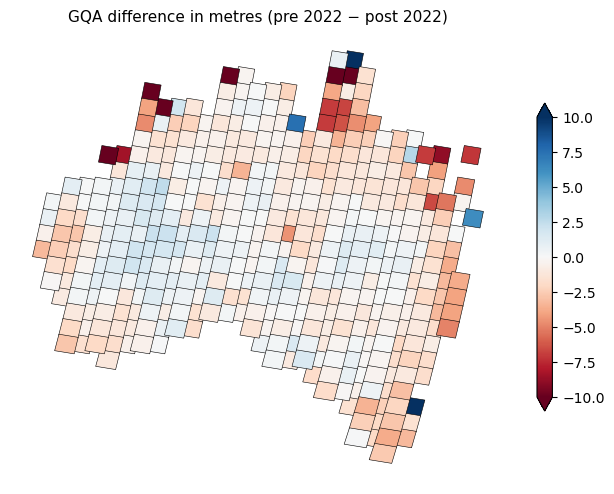

In [34]:
wrs_gdf_subset_joined = wrs_gdf_subset.join(
    pd.Series(gqa_diff_dict, name="gqa_diff")
).join(pd.Series(gqa_n_dict, name="gqa_n")).join(pd.Series(gqa_sig_dict, name="gqa_sig"))

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

wrs_gdf_subset_joined.plot(
    ax=ax,
    column="gqa_diff",
    cmap="RdBu",
    vmin=-10,
    vmax=10,
    edgecolor="black",
    linewidth=0.4,
    legend=True,
    legend_kwds={"shrink": 0.5, "extend": "both"},
)
ax.set_title("GQA difference in metres (pre 2022 − post 2022)", fontsize=11)

ax.set_axis_off()


### Export to file

In [33]:
wrs_gdf_subset_joined.to_file("gqa_diff.geojson")